In [95]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import geopandas as gpd
import numpy as np
from cmdstanpy import CmdStanModel
from sklearn.preprocessing import StandardScaler
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
import itertools
import os
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')



In [96]:
df = gpd.read_file('../data/updated_data.geojson')

In [97]:
y = df["fem_empl_rate"].to_numpy()
y = y / 100
y_star = np.log(y / (1 - y))

selected_covariates = ['fem_house_rate', 'fertility_rate', 'GDP', 'young_neet', 'internet_coverage_rate', 'coverage', 'public_coverage', 'per_capita_public_expenditure', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'ecec_diffusion']
X = df[selected_covariates].to_numpy()
X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

offset = df["mal_empl_rate"].to_numpy()
offset = offset / 100
offset_star = np.log(offset / (1 - offset))

N = 107 
P = len(selected_covariates) 
K = 15

In [98]:
df = df.reset_index(drop=True)

n = len(df)
node1 = []
node2 = []
num_neighbors = np.zeros(n, dtype=int)

sindex = df.sindex  # spatial index

for i, geom in enumerate(df.geometry):
    # candidates using bounding boxes
    possible_matches = list(sindex.intersection(geom.bounds))

    for j in possible_matches:
        if j <= i:
            continue
        if geom.touches(df.geometry[j]):
            node1.append(i + 1)   # Stan is 1-based
            node2.append(j + 1)

            num_neighbors[i] += 1
            num_neighbors[j] += 1

node1 = np.asarray(node1, dtype=int)
node2 = np.asarray(node2, dtype=int)

W = np.zeros((n, n), dtype=int)

for i, j in zip(node1 - 1, node2 - 1):
    W[i, j] = 1
    W[j, i] = 1

## Label Assignment

In [99]:
mix_model = """
data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P] X_star;               
}


parameters {
  simplex[K] pi;           
  ordered[K] alpha;         
  vector[P] beta; 
  real<lower=1e-6> sigma; 
}

model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K)); 

  sigma ~ normal(0, 1);
  
  for (k in 1:K) {
    alpha[k] ~ normal(0, 1);
  }

  for (j in 1:P) {
    beta[j] ~ normal(0, 1);
  }

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha[k] + dot_product(row(X_star, i), beta);
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }
    target += log_sum_exp(lps);
  }
}

generated quantities {
  array[N] int z;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      real mu_ik = alpha[k] + dot_product(row(X_star, i), beta);
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
    
  }
}

"""

In [100]:
with open("normal_mixture_nocar.stan", "w") as f:
    f.write(mix_model)

In [101]:
data = {
    "N": int(N),
    "P": int(P),
    "K": int(K),
    "y_star": y_star.astype(float),
    "X_star": X_star.astype(float),
}


In [102]:
mix_stan = CmdStanModel(stan_file="normal_mixture_nocar.stan")

21:32:15 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_nocar.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_nocar.exe
21:33:49 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_nocar.exe


In [103]:
fit = mix_stan.sample(
    data=data,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.95,
    max_treedepth=12
)

21:33:49 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

21:53:08 - cmdstanpy - INFO - CmdStan done processing.


21:53:08 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 14 divergent transitions (0.7%)
	Chain 2 had 4 divergent transitions (0.2%)
	Chain 3 had 10 divergent transitions (0.5%)
	Chain 4 had 1 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [104]:
fit.column_names

('lp__',
 'accept_stat__',
 'stepsize__',
 'treedepth__',
 'n_leapfrog__',
 'divergent__',
 'energy__',
 'pi[1]',
 'pi[2]',
 'pi[3]',
 'pi[4]',
 'pi[5]',
 'pi[6]',
 'pi[7]',
 'pi[8]',
 'pi[9]',
 'pi[10]',
 'pi[11]',
 'pi[12]',
 'pi[13]',
 'pi[14]',
 'pi[15]',
 'alpha[1]',
 'alpha[2]',
 'alpha[3]',
 'alpha[4]',
 'alpha[5]',
 'alpha[6]',
 'alpha[7]',
 'alpha[8]',
 'alpha[9]',
 'alpha[10]',
 'alpha[11]',
 'alpha[12]',
 'alpha[13]',
 'alpha[14]',
 'alpha[15]',
 'beta[1]',
 'beta[2]',
 'beta[3]',
 'beta[4]',
 'beta[5]',
 'beta[6]',
 'beta[7]',
 'beta[8]',
 'beta[9]',
 'beta[10]',
 'beta[11]',
 'sigma',
 'z[1]',
 'z[2]',
 'z[3]',
 'z[4]',
 'z[5]',
 'z[6]',
 'z[7]',
 'z[8]',
 'z[9]',
 'z[10]',
 'z[11]',
 'z[12]',
 'z[13]',
 'z[14]',
 'z[15]',
 'z[16]',
 'z[17]',
 'z[18]',
 'z[19]',
 'z[20]',
 'z[21]',
 'z[22]',
 'z[23]',
 'z[24]',
 'z[25]',
 'z[26]',
 'z[27]',
 'z[28]',
 'z[29]',
 'z[30]',
 'z[31]',
 'z[32]',
 'z[33]',
 'z[34]',
 'z[35]',
 'z[36]',
 'z[37]',
 'z[38]',
 'z[39]',
 'z[40]',
 'z[

In [ ]:
summary_beta_95 = az.summary(fit, var_names=["beta", "alpha"])
print(summary_beta_95)

alpha_mean = summary_beta_95.loc[summary_beta_95.index.str.startswith("alpha"), "mean"].values
betas_mean = summary_beta_95.loc[summary_beta_95.index.str.startswith("beta"), "mean"].values

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]   -0.340  0.024  -0.384   -0.294      0.000    0.000    2800.0   
beta[1]   -0.233  0.016  -0.264   -0.202      0.000    0.000    4037.0   
beta[2]    0.050  0.022   0.007    0.089      0.000    0.000    3515.0   
beta[3]   -0.077  0.019  -0.114   -0.041      0.000    0.000    4604.0   
beta[4]   -0.041  0.011  -0.060   -0.021      0.000    0.000    4616.0   
beta[5]    0.035  0.016   0.005    0.068      0.000    0.000    5095.0   
beta[6]    0.000  0.016  -0.029    0.030      0.000    0.000    3206.0   
beta[7]    0.035  0.017   0.003    0.067      0.000    0.000    4785.0   
beta[8]    0.005  0.013  -0.020    0.029      0.000    0.000    4177.0   
beta[9]    0.002  0.012  -0.019    0.024      0.000    0.000    4130.0   
beta[10]   0.007  0.012  -0.017    0.028      0.000    0.000    5582.0   
alpha[0]  -1.141  0.664  -2.261   -0.048      0.015    0.008    1762.0   
alpha[1]  -0.562  0.453  -1.397   -0.0

In [106]:
betas_mean

array([-0.34 , -0.233,  0.05 , -0.077, -0.041,  0.035,  0.   ,  0.035,
        0.005,  0.002,  0.007])

In [107]:
alpha_mean

array([-1.141, -0.562, -0.276, -0.131, -0.055, -0.011,  0.021,  0.051,
        0.08 ,  0.11 ,  0.151,  0.216,  0.349,  0.62 ,  1.188])

<Figure size 800x600 with 0 Axes>

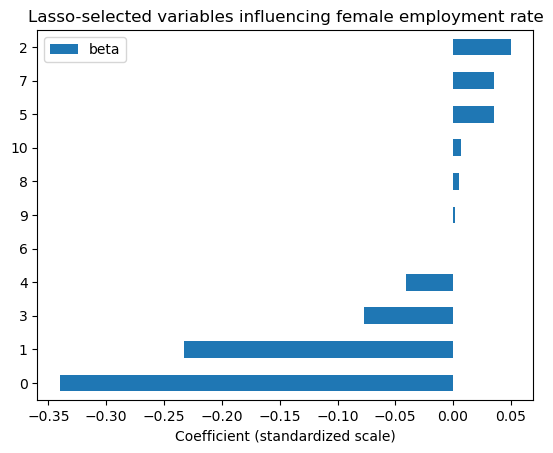

In [108]:
plt.figure(figsize=(8,6))
pd.DataFrame(betas_mean, columns=['beta']).sort_values(by='beta').plot(kind='barh')
plt.title('Lasso-selected variables influencing female employment rate')
plt.xlabel('Coefficient (standardized scale)')
plt.show()

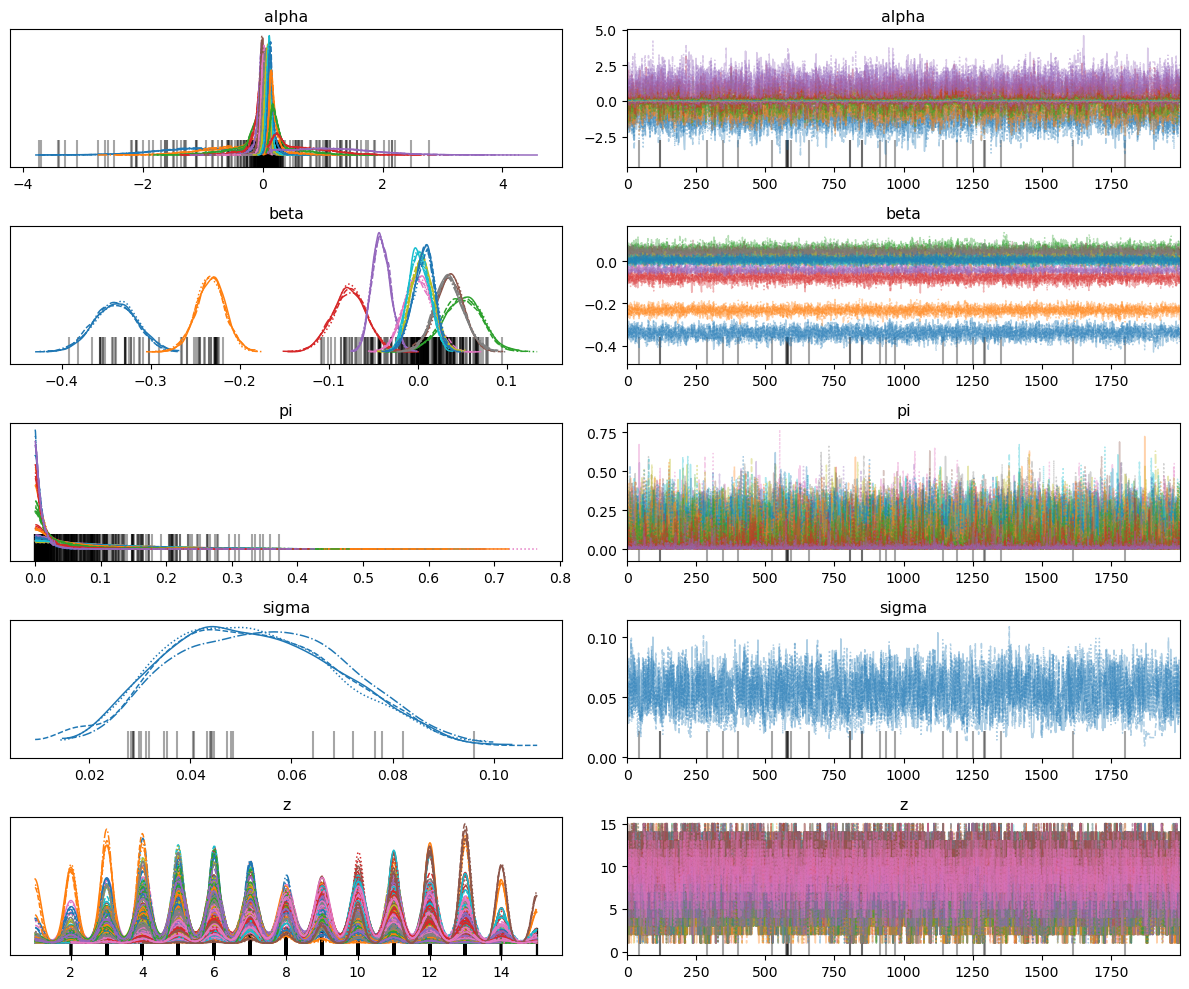

In [ ]:
az.plot_trace(fit)
plt.tight_layout()

In [110]:
fit.stan_variables().keys()

dict_keys(['pi', 'alpha', 'beta', 'sigma', 'z'])

In [111]:
z_draws = fit.stan_variable("z")   # shape: (n_draws, N)

In [112]:
## For each draw:
# - compare couples of observations
# - if they are equal (same label) increment the counter
# - normalize

# At the end psm[i, j] is the posterior probability that observations i and j belong to the same cluster

# Shape is n_draws x n_obs, and the numbers are class labels

@njit
def build_psm(posterior):
    n_draws, n_obs = posterior.shape
    psm = np.zeros((n_obs, n_obs))
    for row in posterior:
        for r_idx, i in enumerate(row):
            for c_idx, j in enumerate(row):
                if i == j:
                    psm[r_idx, c_idx] += 1
                    
    psm /= n_draws
        
    return psm

In [113]:
psm = build_psm(z_draws.astype(np.int64))

In [114]:
def order_by_hclust(psm, method="average"):
    # convert similarity -> distance
    D = 1.0 - psm
    np.fill_diagonal(D, 0.0)
    D = np.clip(D, 0.0, 1.0)

    # linkage needs condensed distances
    condensed = squareform(D, checks=False)
    Z = linkage(condensed, method=method)
    order = leaves_list(Z)   # permutation of 0..N-1
    return order

order = order_by_hclust(psm)
psm_sorted = psm[np.ix_(order, order)]

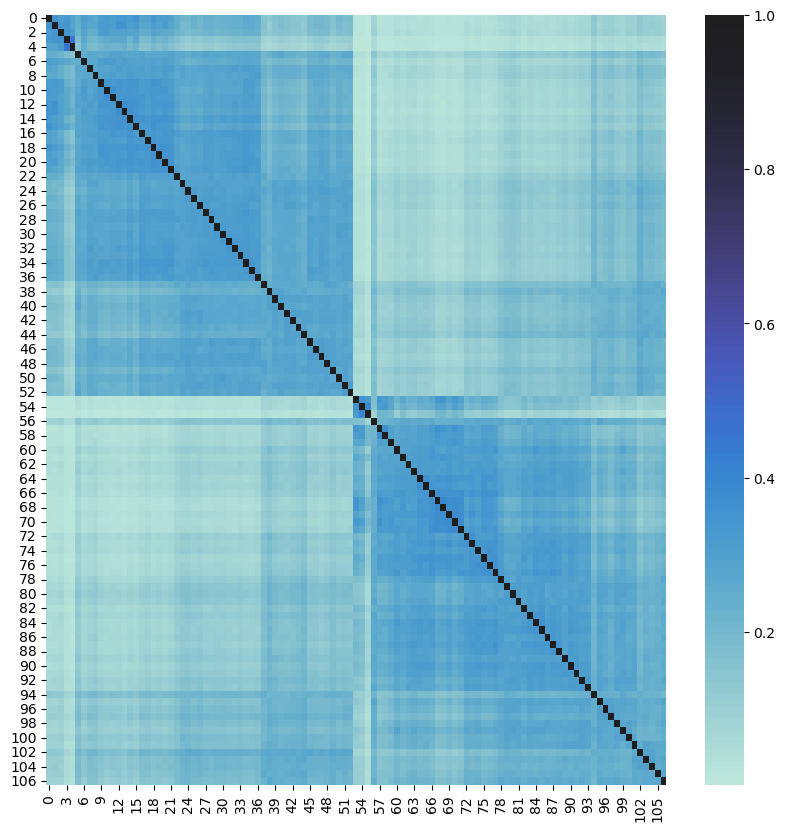

In [115]:
plt.figure(figsize=(10,10))
sns.heatmap(psm_sorted, center=1)
plt.show()

In [116]:
def binder_loss(psm, labels):
    # expected Binder loss from PSM (sum over i<j)
    labels = np.asarray(labels)
    A = (labels[:, None] == labels[None, :]).astype(float)
    iu = np.triu_indices(psm.shape[0], k=1)
    return float(np.sum(np.abs(A[iu] - psm[iu])))

def binder_optimal_partition(psm, k_min, k_max):
    psm = np.asarray(psm, dtype=float)
    psm = 0.5 * (psm + psm.T)
    np.fill_diagonal(psm, 1.0)

    dist = 1.0 - psm
    np.fill_diagonal(dist, 0.0)

    best_loss = np.inf
    best_labels = None

    for k in range(k_min, min(k_max, psm.shape[0]) + 1):
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="average",
            metric="precomputed",  
        )
        labels = model.fit_predict(dist)
        loss = binder_loss(psm, labels)
        if loss < best_loss:
            best_loss = loss
            best_labels = labels

    return best_labels, best_loss

In [117]:
labels_opt, loss_opt = binder_optimal_partition(psm, k_min=1, k_max=5)

In [118]:
loss_opt

1879.831625

In [119]:
labels_opt

array([1, 1, 1, 4, 1, 4, 1, 1, 1, 1, 4, 1, 1, 3, 1, 4, 4, 4, 0, 1, 1, 3,
       1, 1, 4, 1, 2, 1, 4, 1, 4, 0, 0, 4, 1, 3, 0, 1, 0, 1, 4, 1, 1, 4,
       0, 4, 1, 1, 1, 1, 4, 1, 4, 1, 4, 1, 4, 4, 1, 4, 4, 4, 0, 4, 0, 1,
       1, 1, 4, 4, 2, 0, 4, 1, 4, 4, 1, 0, 4, 1, 4, 2, 4, 1, 0, 1, 0, 0,
       1, 3, 1, 4, 4, 1, 1, 1, 1, 4, 4, 1, 4, 4, 4, 1, 4, 3, 1])

In [120]:
labels = labels_opt + 1

In [121]:
labels

array([2, 2, 2, 5, 2, 5, 2, 2, 2, 2, 5, 2, 2, 4, 2, 5, 5, 5, 1, 2, 2, 4,
       2, 2, 5, 2, 3, 2, 5, 2, 5, 1, 1, 5, 2, 4, 1, 2, 1, 2, 5, 2, 2, 5,
       1, 5, 2, 2, 2, 2, 5, 2, 5, 2, 5, 2, 5, 5, 2, 5, 5, 5, 1, 5, 1, 2,
       2, 2, 5, 5, 3, 1, 5, 2, 5, 5, 2, 1, 5, 2, 5, 3, 5, 2, 1, 2, 1, 1,
       2, 4, 2, 5, 5, 2, 2, 2, 2, 5, 5, 2, 5, 5, 5, 2, 5, 4, 2])

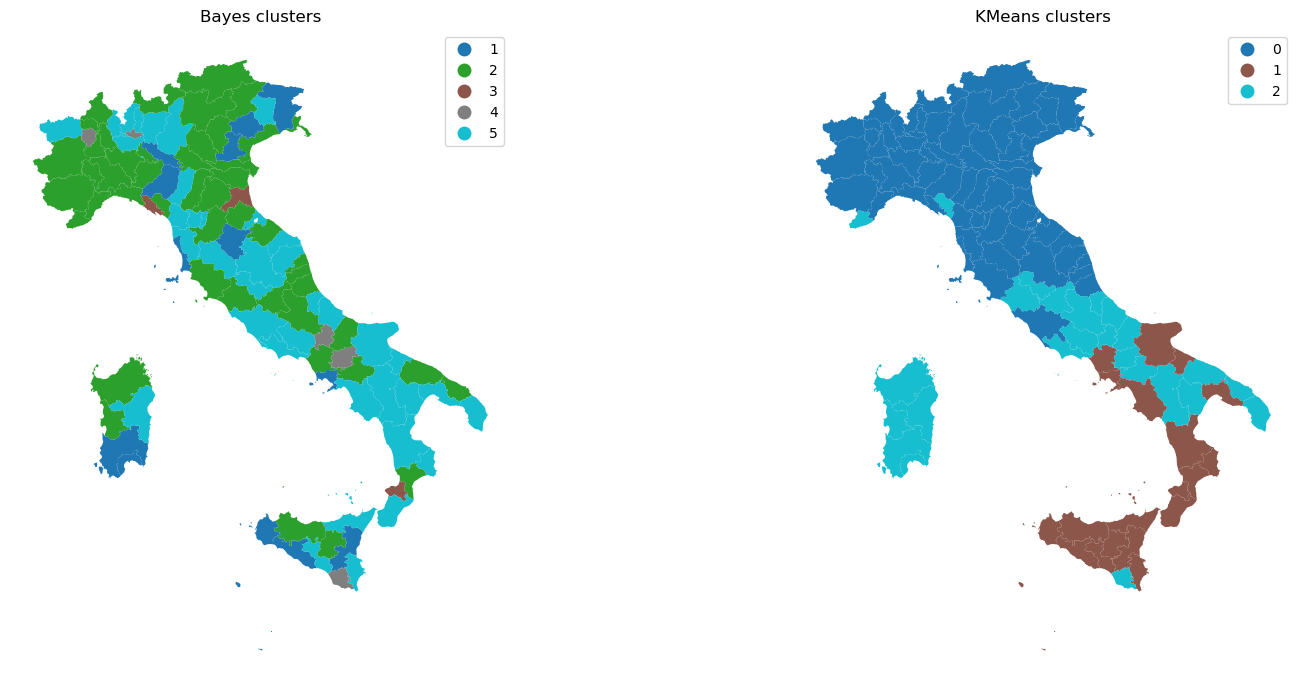

In [122]:
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# gdf: GeoDataFrame with one row per observation/region
# must have a geometry column of polygons/multipolygons
gdf = gpd.read_file("../data/updated_data.geojson")
gdf["cluster_bayes"] = labels

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(y_star.reshape(-1, 1))
gdf["cluster"] = kmeans.labels_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

gdf.plot(column="cluster_bayes", categorical=True, legend=True, ax=ax1)
ax1.set_title("Bayes clusters")
ax1.set_axis_off()

gdf.plot(column="cluster", categorical=True, legend=True, ax=ax2)
ax2.set_title("KMeans clusters")
ax2.set_axis_off()

plt.tight_layout()
plt.show()


In [123]:
with open("labels_nocar.txt", "w") as f:
    for x in labels:
        f.write(f"{x}\n")

## "Final" Model

Actually we still have to add in the model the spatial effect

In [156]:
model = """
data {
  int<lower=1> N;                
  int<lower=1> P;                
  int<lower=1> C;                
  array[N] int<lower=1, upper=C> cluster; // cluster label for each observation (1..C)
  matrix[N, P] X;                
  vector[N] y;                   
}
parameters {
  vector[C] alpha;               // intercept for each cluster
  matrix[C, P] beta;             // coefficient vector (slopes) for each cluster
  vector<lower=1e-6>[C] sigma;      // noise std dev for each cluster
}
model {
  // Priors
  for (c in 1:C) {
    alpha[c] ~ normal(0, 1);
    sigma[c] ~ normal(0, 1);
    for (p in 1:P) {
      beta[c, p] ~ normal(0, 1);
    }
  }

                      

  // Likelihood
  for (n in 1:N) {
    int c = cluster[n];
    y[n] ~ normal(alpha[c] + X[n] * beta[c]', sigma[c]);
  }
}
"""

In [157]:
with open("labeled_model.stan", "w") as f:
    f.write(model)

In [ ]:
C = 5

In [170]:
data_m = {
    "N": int(N),
    "P": int(P),
    "C": int(C),
    "cluster": labels.astype(int),
    "X": X_star.astype(float),
    "y": y_star.astype(float),
}

In [160]:
modell = CmdStanModel(stan_file="labeled_model.stan")

08:35:27 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\labeled_model.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\labeled_model.exe
08:37:57 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\labeled_model.exe


In [171]:
fit = modell.sample(
    data=data_m,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.999,
    max_treedepth=18
)

08:57:46 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

08:57:46 - cmdstanpy - ERROR - Chain [2] error: code '1' Operation not permitted
08:57:46 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
08:57:46 - cmdstanpy - ERROR - Chain [3] error: code '1' Operation not permitted
08:57:46 - cmdstanpy - ERROR - Chain [4] error: code '1' Operation not permitted


08:57:46 - cmdstanpy - INFO - CmdStan done processing.


RuntimeError: Error during sampling:
Exception: labeled_model_model_namespace::labeled_model_model: cluster[1] is 2, but must be less than or equal to 1.000000 (in 'labeled_model.stan', line 6, column 2 to column 41)
Exception: labeled_model_model_namespace::labeled_model_model: cluster[1] is 2, but must be less than or equal to 1.000000 (in 'labeled_model.stan', line 6, column 2 to column 41)
Exception: labeled_model_model_namespace::labeled_model_model: cluster[1] is 2, but must be less than or equal to 1.000000 (in 'labeled_model.stan', line 6, column 2 to column 41)
Exception: labeled_model_model_namespace::labeled_model_model: cluster[1] is 2, but must be less than or equal to 1.000000 (in 'labeled_model.stan', line 6, column 2 to column 41)
Command and output files:
RunSet: chains=4, chain_ids=[1, 2, 3, 4], num_processes=4
 cmd (chain 1):
	['C:\\Users\\leona\\Desktop\\POLIMI\\Programmi\\BayesianStat\\Bayesian-Statistics-Project\\sandbox\\mixture_model\\labeled_model.exe', 'id=1',

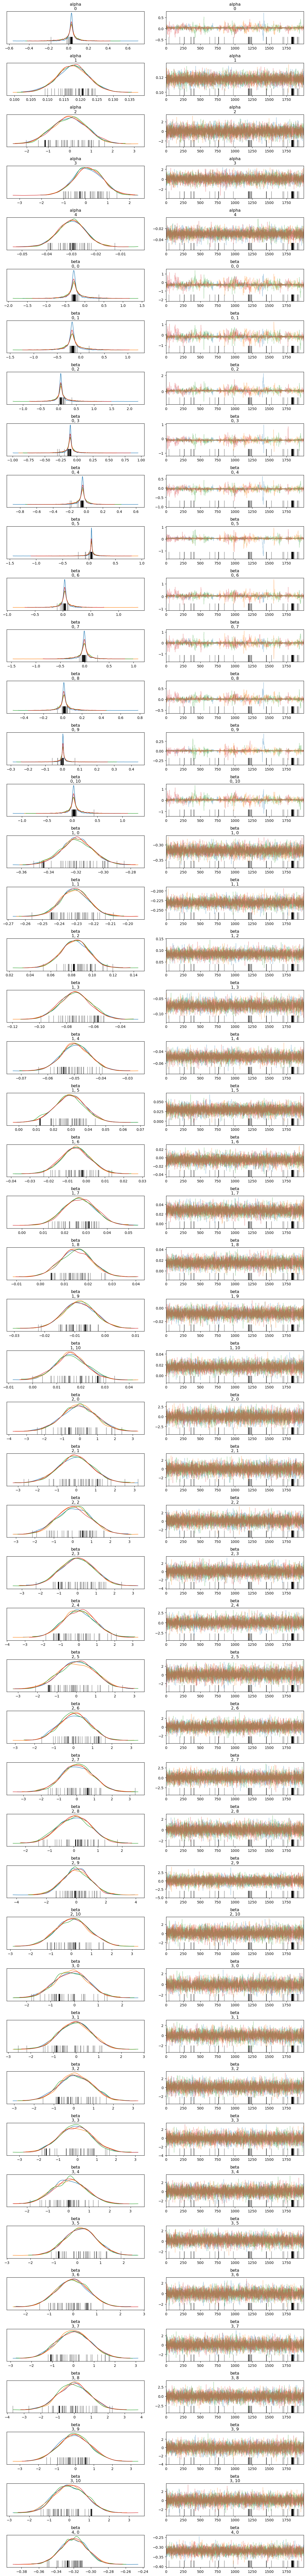

In [168]:
az.rcParams["plot.max_subplots"] = 100   
az.plot_trace(fit, compact=False)
plt.tight_layout()
# az.plot_trace(fit)
#  plt.tight_layout()

In [151]:
summary_beta_95 = az.summary(fit, var_names=["beta", "alpha"])
print(summary_beta_95)

alpha_mean = summary_beta_95.loc[summary_beta_95.index.str.startswith("alpha"), "mean"].values
betas_mean = summary_beta_95.loc[summary_beta_95.index.str.startswith("beta"), "mean"].values

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0, 0]  -0.375  0.683  -1.843    1.008      0.068    0.072     125.0   
beta[0, 1]  -0.260  0.570  -1.461    0.966      0.054    0.058     135.0   
beta[0, 2]   0.005  0.518  -1.001    1.131      0.048    0.060     143.0   
beta[0, 3]  -0.076  0.240  -0.534    0.454      0.016    0.026     271.0   
beta[0, 4]  -0.018  0.210  -0.424    0.429      0.020    0.023     134.0   
beta[0, 5]   0.054  0.234  -0.406    0.495      0.010    0.031     754.0   
beta[0, 6]  -0.005  0.313  -0.738    0.577      0.024    0.031     186.0   
beta[0, 7]   0.047  0.418  -0.785    0.955      0.035    0.043     167.0   
beta[0, 8]  -0.014  0.200  -0.441    0.377      0.019    0.023     142.0   
beta[0, 9]   0.003  0.077  -0.125    0.143      0.004    0.011     530.0   
beta[0, 10] -0.020  0.398  -0.992    0.692      0.038    0.043     143.0   
beta[1, 0]  -0.319  0.012  -0.342   -0.297      0.000    0.000    2412.0   
beta[1, 1]  